# **EDA Notebook**

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt 


In [3]:
#Import parquet into dataframe

file_path = Path("../data") / "processed" / "data_final.parquet"

df = pd.read_parquet(file_path)

df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of Facility TE Measures,TE Group Footnote,MORT_fac_rate,MORT_bet_rate,Safety_fac_rate,Safety_bet_rate,READM_fac_rate,READM_bet_rate,PtExp_fac_rate,TE_fac_rate
0,10001,southeast health medical center,1108 ross clark circle,dothan,al,36301,houston,(334) 793-8701,acute care hospitals,government - hospital district or authority,...,11.0,<NA>,1.000000,0.0,0.875,0.428571,1.000000,0.0,1.0,0.916667
1,10005,marshall medical centers,2505 u s highway 431 north,boaz,al,35957,marshall,(256) 593-8310,acute care hospitals,government - hospital district or authority,...,12.0,<NA>,0.857143,0.0,0.875,0.000000,0.818182,0.0,1.0,1.000000
2,10006,north alabama medical center,1701 veterans drive,florence,al,35630,lauderdale,(256) 768-8400,acute care hospitals,proprietary,...,10.0,<NA>,1.000000,0.0,1.000,0.375000,0.818182,0.0,1.0,0.833333
3,10007,mizell memorial hospital,702 n main st,opp,al,36467,covington,(334) 493-3541,acute care hospitals,voluntary non-profit - private,...,7.0,<NA>,0.428571,0.0,0.375,0.000000,0.636364,0.0,1.0,0.583333
4,10008,crenshaw community hospital,101 hospital circle,luverne,al,36049,crenshaw,(334) 335-3374,acute care hospitals,proprietary,...,6.0,<NA>,0.142857,0.0,NaN,NaN,0.181818,0.0,NaN,0.500000


In [4]:
#Explore basic properties of dataset columns

print(f"The total number of facilities is {len(df['Facility ID'])}.\n")
print(f"The number of unique facilities is {len(df['Facility ID'].unique())}.\n")
print(f"Do duplicate entries exist?: {len(df['Facility ID'])!=len(df['Facility ID'].unique())}\n")
print(f"Count of NAs:\n\n{df.isna().sum()}")

The total number of facilities is 5426.

The number of unique facilities is 5426.

Do duplicate entries exist?: False

Count of NAs:

Facility ID                                            0
Facility Name                                          0
Address                                                0
City/Town                                              0
State                                                  0
ZIP Code                                               0
County/Parish                                          0
Telephone Number                                       0
Hospital Type                                          0
Hospital Ownership                                     0
Emergency Services                                     0
Meets criteria for birthing friendly designation       0
Hospital overall rating                             2560
Hospital overall rating footnote                    2854
MORT Group Measure Count                             875
Count of Fa

In [5]:
#Explore descriptive statistics of dataset columns

print(df.describe())

       Hospital overall rating  MORT Group Measure Count  \
count              2866.000000                    4551.0   
mean                  3.081647                       7.0   
std                   1.099404                       0.0   
min                   1.000000                       7.0   
25%                   2.000000                       7.0   
50%                   3.000000                       7.0   
75%                   4.000000                       7.0   
max                   5.000000                       7.0   

       Count of Facility MORT Measures  Count of MORT Measures Better  \
count                      3640.000000                    3640.000000   
mean                          4.389011                       0.229945   
std                           2.127120                       0.675919   
min                           1.000000                       0.000000   
25%                           2.000000                       0.000000   
50%                  

In [6]:
#Determine missingness of each column

count_na = df.isna().sum()
missingness_calc = count_na / len(df['Facility ID'])

print(missingness_calc)

Facility ID                                         0.000000
Facility Name                                       0.000000
Address                                             0.000000
City/Town                                           0.000000
State                                               0.000000
ZIP Code                                            0.000000
County/Parish                                       0.000000
Telephone Number                                    0.000000
Hospital Type                                       0.000000
Hospital Ownership                                  0.000000
Emergency Services                                  0.000000
Meets criteria for birthing friendly designation    0.000000
Hospital overall rating                             0.471802
Hospital overall rating footnote                    0.525986
MORT Group Measure Count                            0.161261
Count of Facility MORT Measures                     0.329156
Count of MORT Measures B

In [7]:
df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type',
       'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation',
       'Hospital overall rating', 'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Gr

In [8]:
df['Meets criteria for birthing friendly designation'].unique()

array([ True, False])

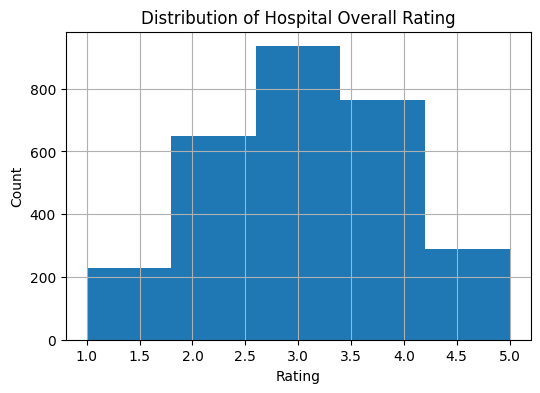

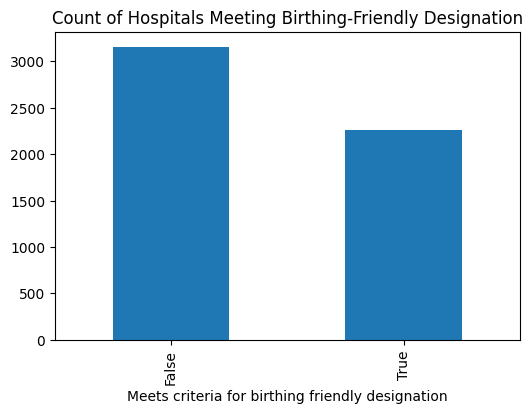

Text(0, 0.5, 'Overall Measure Count')

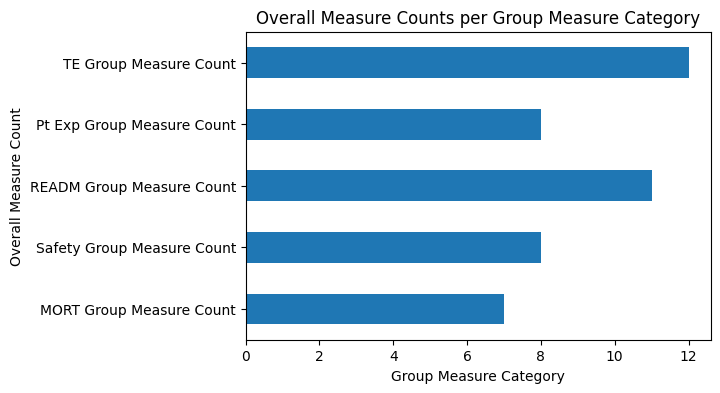

In [12]:
#Plot distributions of columns of interest

measure_counts = ['MORT Group Measure Count', 'Safety Group Measure Count', 
                  'READM Group Measure Count', 'Pt Exp Group Measure Count', 
                  'TE Group Measure Count']
cols_of_int = ['State', 'ZIP Code', 'Hospital Type', 'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation', 'Hospital overall rating', 
       'Count of Facility MORT Measures', 'Count of MORT Measures Better', 
       'Count of Facility Safety Measures', 'Count of Safety Measures Better', 
       'Count of Facility READM Measures', 'Count of READM Measures Better',
       'Count of Facility Pt Exp Measures', 'Count of Facility TE Measures',
       'MORT_fac_rate', 'MORT_bet_rate', 'Safety_fac_rate', 'Safety_bet_rate', 
       'READM_fac_rate', 'READM_bet_rate', 'PtExp_fac_rate', 'TE_fac_rate']


#Plot overall rating and birthing

plt.figure(figsize=(6,4))
df['Hospital overall rating'].dropna().hist(bins=5)
plt.title("Distribution of Hospital Overall Rating")
plt.xlabel("Rating")
plt.ylabel("Count")


#Plot Meets birthing-friendly designation
plt.figure(figsize=(6,4))
df['Meets criteria for birthing friendly designation'].value_counts().plot(kind='bar')
plt.title("Count of Hospitals Meeting Birthing-Friendly Designation")
plt.show()


#Plot number of measure counts per outcome
plt.figure(figsize=(6,4))
df[measure_counts].max().dropna().plot(kind='barh')
plt.title("Overall Measure Counts per Group Measure Category")
plt.xlabel("Group Measure Category")
plt.ylabel("Overall Measure Count")


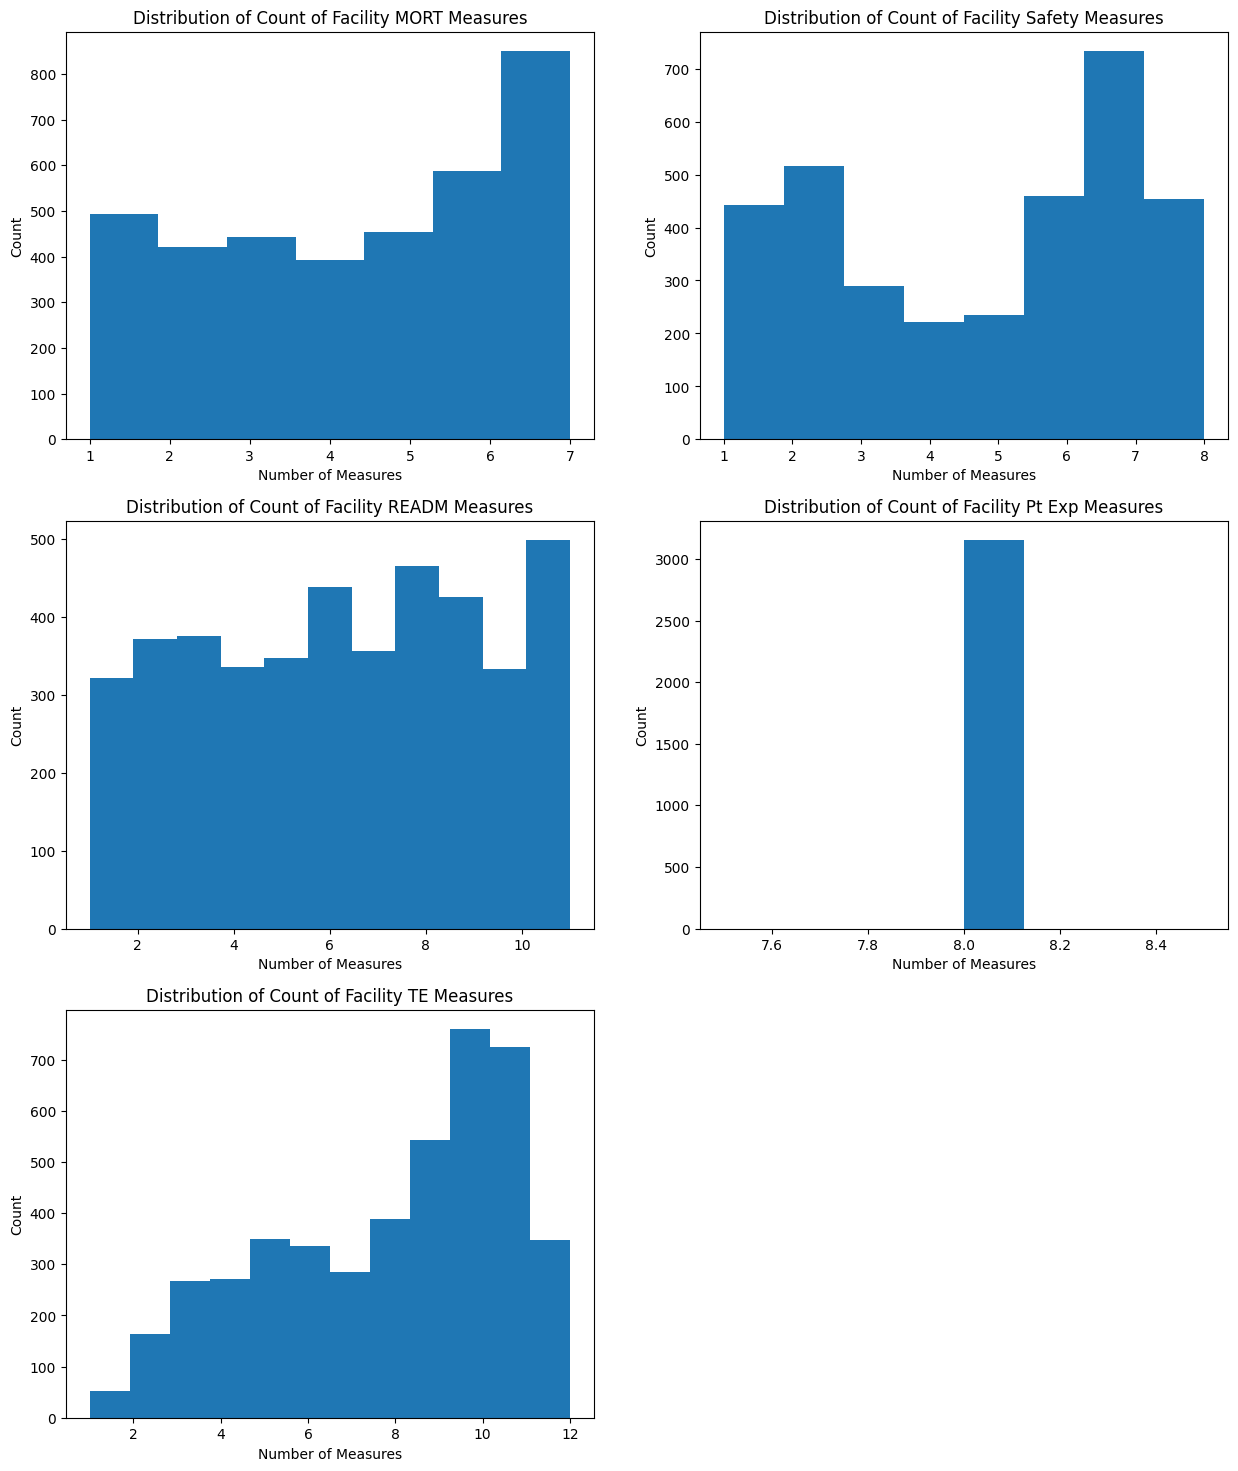

In [10]:
#Plot Facility measure counts with static line for overall group count for each category

fac_list = []
bet_list = []

for col in cols_of_int:
    if 'facility' in col.lower():
        fac_list.append(col)
    elif 'better' in col.lower():
        bet_list.append(col)

fig, axes = plt.subplots(3, 2, figsize=(15,18))
axes = axes.ravel()

for i,fac in enumerate(fac_list):
    axes[i].hist(df[fac].dropna(), bins=int(df[fac].dropna().max()))
    axes[i].set_title(f'Distribution of {fac}')
    axes[i].set_xlabel('Number of Measures')
    axes[i].set_ylabel('Count')
    #for mx in measure_counts:
    #    if fac.split()[-2] in mx:
    #        plt.axvline(int(df[mx].dropna().max()), linewidth=2, color='orange')
fig.delaxes(axes[5])